In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [14]:
u_inf = 20 #m/s
alpha_deg = 2
rho = 1.225

number_chordwise_panels = 8
number_spanwise_nodes = 16
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [15]:
case_name = "itWillFlutter"
route_test_dir = os.path.abspath('')

length = 1.2
width = 0.08
height = 0.005
c_ref= 0.2
massperunit = 14

pazy_altered = wings.PazyControlSurface(
    M = number_chordwise_panels,
    N = number_spanwise_nodes,
    Mstar_fact=10,
    u_inf=u_inf,
    alpha=alpha_deg,
    cs_deflection=[0,0],
    n_control_surfaces=2,
    rho=rho,
    tip_rod=True,
    b_ref=2.*length,
    main_chord=c_ref,
    pct_flap=0.2,
    aspect_ratio=2*c_ref/length,
    n_surfaces=2,
    physical_time=2,
    route = cases_folder + '/' + case_name,
    case_name=case_name,
    #physical_time = simulation_time,
)

In [16]:
def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = massperunit
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    self.main_ea = 0.33
    self.main_cg = 0.53

pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

In [17]:
pazy_altered.clean_test_files()
pazy_altered.update_derived_params()
pazy_altered.set_default_config_dict()

pazy_altered.generate_aero_file()
pazy_altered.generate_fem_file()

8.333333333333335e-10
2.1333333333333336e-07
[[2.76000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.04000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.04000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.73333333e+02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.75000000e+01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.47200000e+04]]
2.141666666666667e-07
0.0005782500000000001


In [18]:
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

pazy_altered.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': pazy_altered.case_name, 'route': pazy_altered.route,
    'write_screen': 'on', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': pazy_altered.case_name + '.log'
}

pazy_altered.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_altered.quat}

pazy_altered.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': pazy_altered.Mstar_fact * pazy_altered.M,
    'freestream_dir': pazy_altered.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': pazy_altered.u_inf,
                                    'u_inf_direction': pazy_altered.u_inf_direction,
                                    'dt': pazy_altered.dt}}

pazy_altered.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': pazy_altered.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': pazy_altered.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': pazy_altered.u_inf,
            'u_inf_direction': pazy_altered.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

pazy_altered.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': pazy_altered.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': 20,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_altered.dt,
                                                      'ScalingDict': {'length': 0.5 * pazy_altered.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': pazy_altered.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

pazy_altered.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 70, 81],
                                   'modes_to_plot': []}
                                    

pazy_altered.config.write()

In [19]:
sharpy_output = sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	/home/user/sharpy/sharpy/output//itWillFlutte

|  0  |  0  |  0.00000   |  0.3184  |  0.0000  | -9.0874  |  0.0000  |  0.0095  |  0.0000  |
|  1  |  0  |    -inf    |  0.3184  |  0.0000  | -9.0874  |  0.0000  |  0.0095  |  0.0000  |
Generating an instance of AerogridPlot
Variable include_forward_motion has no assigned value in the settings file.
    will default to the value: False
Variable include_unsteady_applied_forces has no assigned value in the settings file.
    will default to the value: False
Variable name_prefix has no assigned value in the settings file.
    will default to the value: 
Variable u_inf has no assigned value in the settings file.
    will default to the value: 0.0
Variable dt has no assigned value in the settings file.
    will default to the value: 0.0
Variable include_velocities has no assigned value in the settings file.
    will default to the value: False
Variable include_incidence_angle has no assigned value in the settings file.
    will default to the value: False
Variable plot_nonlifting_surfaces h

fatal: not a git repository (or any of the parent directories): .git


|      0       |   0.000000   | 6286.740310  | 1000.565796  | 1000.565796  |  -0.000000   |   0.000999   |
|      1       |   0.000000   | 6286.740477  | 1000.565823  | 1000.565823  |  -0.000000   |   0.000999   |
|      2       |   0.000000   | 25935.359206 | 4127.740618  | 4127.740618  |  -0.000000   |   0.000242   |
|      3       |   0.000000   | 25935.359514 | 4127.740667  | 4127.740667  |  -0.000000   |   0.000242   |
|      4       |   0.000000   | 35658.643707 | 5675.249410  | 5675.249410  |  -0.000000   |   0.000176   |
|      5       |   0.000000   | 35658.643987 | 5675.249455  | 5675.249455  |  -0.000000   |   0.000176   |
|      6       |   0.000000   | 37889.413077 | 6030.287382  | 6030.287382  |  -0.000000   |   0.000166   |
|      7       |   0.000000   | 37889.413077 | 6030.287382  | 6030.287382  |  -0.000000   |   0.000166   |
|      8       |   0.000000   | 66138.337330 | 10526.243314 | 10526.243314 |  -0.000000   |   0.000095   |
|      9       |   0.000000   | 66138

/home/user/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


	state-space model produced in form:
			h_{n+1} = A h_{n} + B u_{n}
			with:
	x_n = h_n + Bp u_n
			...done in 1.03 sec
Scaling UVLM system with reference time 0.005000s
Non-dimensional time step set (0.250000)
System scaled in 0.620735s
Generating an instance of LinearBeam
Variable remove_rigid_states has no assigned value in the settings file.
    will default to the value: False
Warning, projecting system with damping onto undamped modes

Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -9.50 6.05 0.00
Node  1 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.004 -0.000
			-> G 0.000 0.004 -0.000
	Node mass:
		Matrix: 0.0622
Node  2 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.008 -0.000
			-> G 0.000 0.008 -0.000
	Node mass:
		Matrix: 0.0311
Node  3 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.013 -0.000
			-> G 0.000 0.013 -0.000
	Node mass:
		Matrix: 0.0622
Node  4 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.017 -0.000
			-> G 0.000 0.017 -0.000
	Node mass:
		Matrix: 0.0311
Node  5 	-> B -0.

/home/user/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '


Model Order Reduction in progress...
Moment Matching Krylov Model Reduction
	Construction Algorithm:
		mimo_rational_arnoldi
	Interpolation points:
		sigma = 0.000000 + 0.000000j [rad/s]

	Krylov order:
		r = 6
	Constructing controllability space
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 16
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 18
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 21
		Vector deflated
	Matrix lost orthogonality creating Krylov subspace: 
		Krylov order = 2
		Input vector = 23
		Vector deflated
	Constructing observability space
	Deflating column 22
	Deflating column 23
	Deflating column 24
	Deflating column 25
	Deflating column 26
	Deflating column 27
	Deflating column 28
	Deflating column 29
	Deflating column 30
	Deflating column 31
	Deflating column 32
	Deflating column 33
	Deflating column 34
	D

/home/user/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning: Reduced Order Model Unstable
  warn.warn('Reduced Order Model Unstable')


Dynamical System Eigenvalues - aeroelastic system



|==============|==============|==============|==============|==============|==============|==============|
|     mode     |  eval_real   |  eval_imag   | freq_n (Hz)  | freq_d (Hz)  |   damping    |  period (s)  |
|==============|==============|==============|==============|==============|==============|==============|
|      0       |   1.956254   |   9.414030   |   1.530297   |   1.498289   |  -0.203456   |   0.667428   |
|      1       |   1.956254   |  -9.414030   |   1.530297   |   1.498289   |  -0.203456   |   0.667428   |
|      2       |   1.271378   |  -1.046666   |   0.262095   |   0.166582   |  -0.772035   |   6.003049   |
|      3       |   1.271378   |   1.046666   |   0.262095   |   0.166582   |  -0.772035   |   6.003049   |
|      4       |   0.799084   |   0.000000   |   0.127178   |   0.000000   |   1.000000   |     inf      |
|      5       |   0.461390   |   1.574313   |   0.261099   |   0.250560   |  -0.281245   |

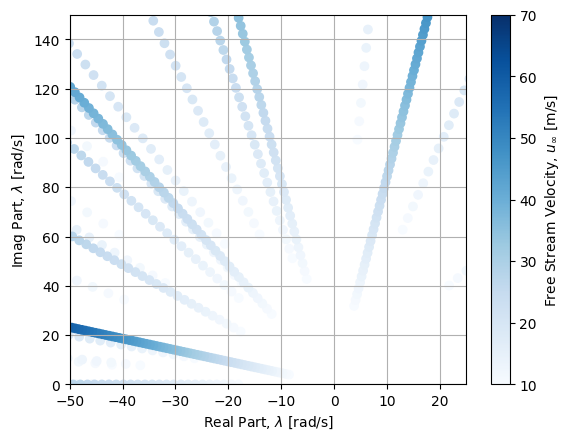

In [20]:
file_name = './output/%s/stability/velocity_analysis_min0100_max0700_nvel0081.dat' % case_name
%matplotlib inline
velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 25)
plt.ylim(0, 150)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

[ 7.72035024e-01  7.72035024e-01  1.00000000e+00 ... -3.30363280e-05  2.03454107e-01  2.03454107e-01]


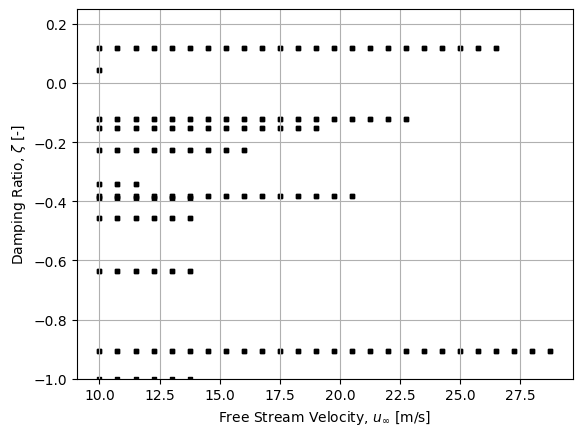

In [21]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)
print(damping_ratio)
plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

[ 164.67883769  164.67883769   79.90837657 ... 8600.62480611 6730.59560256 6730.59560256]


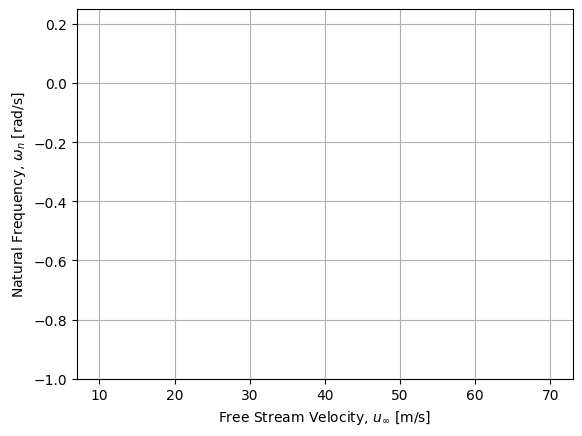

In [22]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
print(natural_frequency)
plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');

8.333333333333335e-10
42.98761028030032


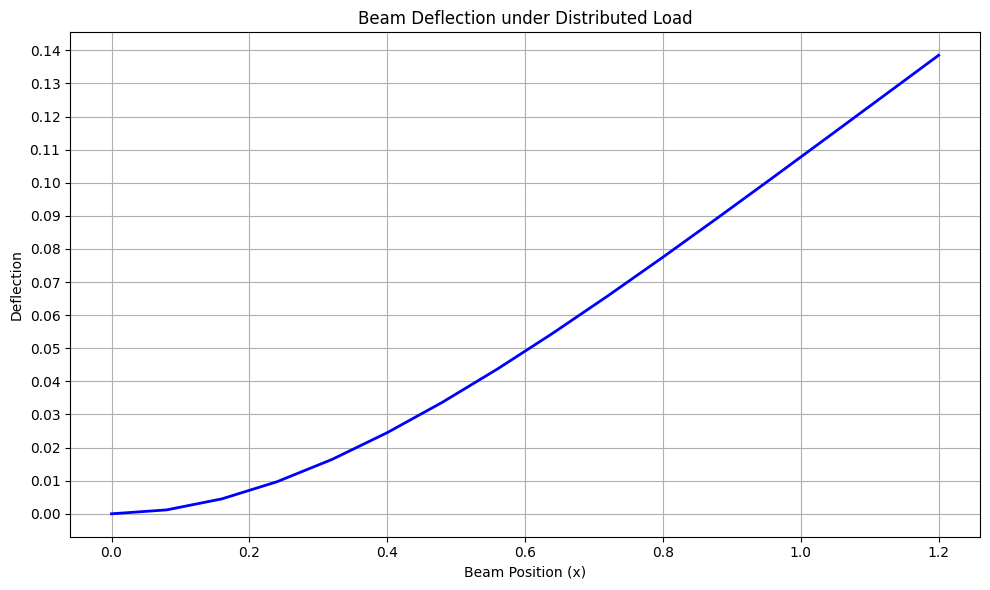

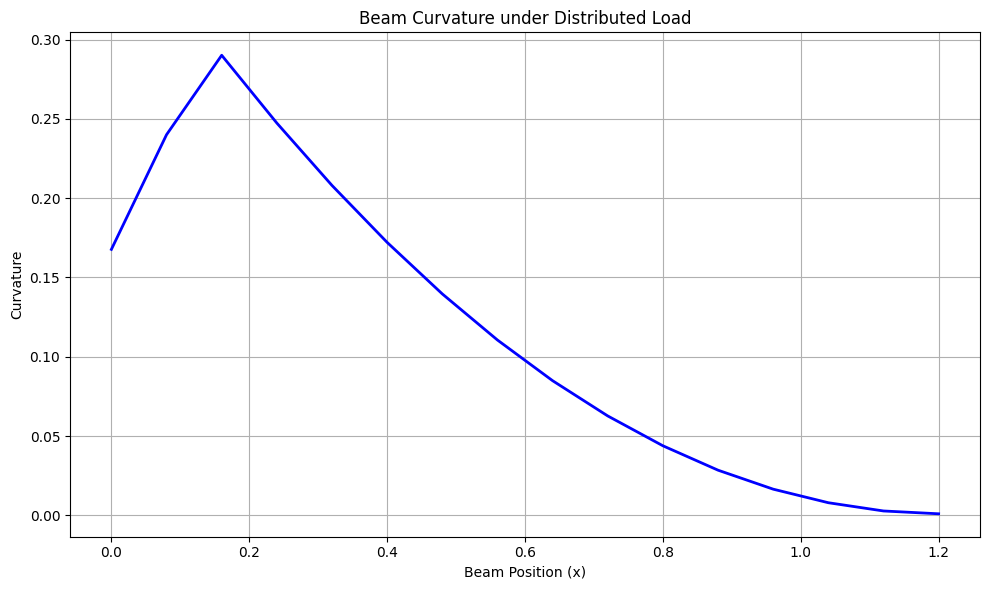

In [23]:
import numpy as np

# Constants
rho = 1.225  # air density (kg/m^3) at atmospheric conditions
V = 40 # velocity (m/s)
chord = c_ref  # chord length (m)
span = length  # span (m)
E = 69e9  # Young's modulus for aluminum (Pa)
I = (width * height**3) / 12  # moment of inertia (m^4)
print(I)
CL = 2*np.pi  # Adjusted lift coefficient for NACA 0012 at 2 degrees AoA
aoa = np.radians(2)  # angle of attack in radians

# Aerodynamic forces
q = 0.5 * rho * V**2  # dynamic pressure (Pa)
L_per_span = q * CL * aoa * chord  # lift per unit span (N/m)
print(L_per_span)

# Beam deflection
x = np.linspace(0,span,number_spanwise_nodes)
deflection = (((L_per_span - 9.81*1.25) * x**2) / (24 * E * I)) * (x**2 + 6 * span**2 - 4 * span * x)

plt.figure(figsize=(10, 6))
plt.plot(x, deflection, 'b-', linewidth=2)
plt.title('Beam Deflection under Distributed Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Deflection')
plt.grid(True)
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.01))
plt.tight_layout()
plt.show()

d_deflection_dx = np.gradient(deflection, x)
d2_deflection_dx2 = np.gradient(d_deflection_dx, x)
plt.figure(figsize=(10, 6))
plt.plot(x, d2_deflection_dx2, 'b-', linewidth=2)
plt.title('Beam Curvature under Distributed Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Curvature')
plt.grid(True)
plt.tight_layout()
plt.show()
